### Importing Libraries

The required libraries are imported to handle data processing, embeddings, and similarity computation.

In [1]:
import json
import re
import numpy as np
import pandas as pd

from gensim.downloader import load
from sklearn.metrics.pairwise import cosine_similarity

### Loading Data

The dataset is loaded from the JSON file containing WordNet synsets, including hypernyms and hyponyms for each term.

In [2]:
with open("wordnet_term_details.json", "r", encoding="utf-8") as f:
    data = json.load(f)

len(data)

42

### Structuring the Data

The JSON structure is transformed into a tabular format where each row represents a relation (hypernym or hyponym) associated with a given term.

In [3]:
rows = []

for item in data:
    term = item["term"]
    
    for h in item["hypernyms"]:
        rows.append({
            "main_term": term,
            "related_term": h,
            "relation_type": "hypernym"
        })
        
    for h in item["hyponyms"]:
        rows.append({
            "main_term": term,
            "related_term": h,
            "relation_type": "hyponym"
        })

df = pd.DataFrame(rows)

df.head()

,main_term,related_term,relation_type
0,male monarch,adult male,hypernym
1,male monarch,crowned head,hypernym
2,male monarch,man,hypernym
3,male monarch,monarch,hypernym
4,male monarch,sovereign,hypernym


### Text Preprocessing

Terms are normalized by converting them to lowercase, removing punctuation, and standardizing multi-word expressions. This ensures consistency for embedding lookup.

In [4]:
def preprocess_term(term):
    term = term.lower()
    term = term.replace("-", " ")
    term = re.sub(r"[^a-z\s]", "", term)
    term = re.sub(r"\s+", " ", term).strip()
    return term

df["clean_term"] = df["related_term"].apply(preprocess_term)

df.head()

,main_term,related_term,relation_type,clean_term
0,male monarch,adult male,hypernym,adult male
1,male monarch,crowned head,hypernym,crowned head
2,male monarch,man,hypernym,man
3,male monarch,monarch,hypernym,monarch
4,male monarch,sovereign,hypernym,sovereign


### Cleaning the Data

Empty or invalid terms are removed to avoid errors during embedding computation.

In [5]:
df = df[df["clean_term"] != ""].copy()

df.head()

,main_term,related_term,relation_type,clean_term
0,male monarch,adult male,hypernym,adult male
1,male monarch,crowned head,hypernym,crowned head
2,male monarch,man,hypernym,man
3,male monarch,monarch,hypernym,monarch
4,male monarch,sovereign,hypernym,sovereign


### Loading Embedding Space

A pre-trained GloVe embedding model is loaded to represent words as vectors in a semantic space.

In [6]:
glove = load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


### Vector Representation

A function is defined to compute vector representations. Multi-word expressions are handled by averaging the vectors of individual words.

In [7]:
def get_vector(term, model):
    words = term.split()
    vectors = []
    
    for word in words:
        if word in model:
            vectors.append(model[word])
    
    if len(vectors) == 0:
        return None
    
    return np.mean(vectors, axis=0)

### Testing Multi-word Handling

Sample terms are tested to verify that both single and multi-word expressions are correctly mapped to vector representations.

In [8]:
test_terms = ["king", "crown princess", "mother in law", "lady of the house"]

for t in test_terms:
    clean = preprocess_term(t)
    vector = get_vector(clean, glove)
    print(t, "->", "OK" if vector is not None else "MISSING")

king -> OK
crown princess -> OK
mother in law -> OK
lady of the house -> OK


### Defining Semantic Categories

A set of semantic categories is defined to group terms into meaningful conceptual domains such as authority, family, and social status.

In [9]:
categories = {
    "authority_power": [
        "power", "authority", "leader", "ruler", "king", "queen",
        "sovereign", "monarch", "officer", "bishop", "priest"
    ],
    "social_status": [
        "status", "rank", "class", "aristocrat", "noble",
        "superior", "patrician", "elite"
    ],
    "family_relation": [
        "family", "parent", "mother", "father", "wife", "husband",
        "son", "daughter", "sibling", "uncle", "aunt", "spouse"
    ],
    "gender_marked": [
        "woman", "man", "female", "male", "girl", "boy",
        "lady", "gentleman"
    ],
    "profession_role": [
        "job", "profession", "worker", "actor", "waiter",
        "businessperson", "police", "server", "performer"
    ]
}

### Category Representation

Each category is represented as a centroid vector, computed as the average of its defining words in the embedding space.

In [10]:
category_vectors = {}

for category, words in categories.items():
    vectors = []
    
    for word in words:
        clean_word = preprocess_term(word)
        vector = get_vector(clean_word, glove)
        
        if vector is not None:
            vectors.append(vector)
    
    category_vectors[category] = np.mean(vectors, axis=0)

category_vectors.keys()

dict_keys(['authority_power', 'social_status', 'family_relation', 'gender_marked', 'profession_role'])

### Semantic Classification

Each term is assigned to a category based on cosine similarity with category vectors, selecting the most similar category.

In [11]:
def classify_term(term, model, category_vectors):
    term_vector = get_vector(term, model)
    
    if term_vector is None:
        return pd.Series({
            "assigned_category": "missing_embedding",
            "similarity_score": np.nan
        })
    
    scores = {}
    
    for category, category_vector in category_vectors.items():
        score = cosine_similarity(
            term_vector.reshape(1, -1),
            category_vector.reshape(1, -1)
        )[0][0]
        scores[category] = score
    
    best_category = max(scores, key=scores.get)
    
    return pd.Series({
        "assigned_category": best_category,
        "similarity_score": scores[best_category]
    })

df[["assigned_category", "similarity_score"]] = df["clean_term"].apply(
    lambda x: classify_term(x, glove, category_vectors)
)

df.head(20)

,main_term,related_term,relation_type,clean_term,assigned_category,similarity_score
0,male monarch,adult male,hypernym,adult male,gender_marked,0.766569
1,male monarch,crowned head,hypernym,crowned head,authority_power,0.655914
2,male monarch,man,hypernym,man,gender_marked,0.848216
3,male monarch,monarch,hypernym,monarch,authority_power,0.746269
4,male monarch,sovereign,hypernym,sovereign,authority_power,0.575652
5,male monarch,King of England,hyponym,king of england,authority_power,0.790587
6,male monarch,King of France,hyponym,king of france,authority_power,0.793523
7,male monarch,King of Great Britain,hyponym,king of great britain,authority_power,0.816467
8,male monarch,King of the Germans,hyponym,king of the germans,authority_power,0.758873
9,female monarch,female aristocrat,hypernym,female aristocrat,gender_marked,0.805119


### Handling Missing Embeddings

Terms that cannot be represented in the embedding space are identified for inspection or exclusion.

In [12]:
missing = df[df["assigned_category"] == "missing_embedding"]

missing[["related_term", "clean_term"]].drop_duplicates()

,related_term,clean_term
33,maharanee,maharanee
65,mimer,mimer
68,pantomimer,pantomimer
69,pantomimist,pantomimist
72,playactor,playactor
84,upstager,upstager
88,histrion,histrion
99,counterperson,counterperson
126,pointsman,pointsman
159,mompreneur,mompreneur


### Category Distribution

The frequency of each category is computed to obtain an overview of the semantic distribution.

In [13]:
category_counts = df["assigned_category"].value_counts()

category_counts

assigned_category
gender_marked        97
authority_power      78
family_relation      75
profession_role      44
social_status        23
missing_embedding    19
Name: count, dtype: int64

### Linking Gender Information

The dataset is enriched by merging gender labels, enabling comparison between masculine and feminine terms.

In [14]:
pairs = pd.read_csv("wordnet_gender_pairs_clean_sparql.csv")

pairs_small = pairs[["term", "gender_side", "pair_male", "pair_female"]]

df = df.merge(
    pairs_small,
    left_on="main_term",
    right_on="term",
    how="left"
)

df.head()

,main_term,related_term,relation_type,clean_term,assigned_category,similarity_score,term,gender_side,pair_male,pair_female
0,male monarch,adult male,hypernym,adult male,gender_marked,0.766569,male monarch,male,male monarch,female monarch
1,male monarch,crowned head,hypernym,crowned head,authority_power,0.655914,male monarch,male,male monarch,female monarch
2,male monarch,man,hypernym,man,gender_marked,0.848216,male monarch,male,male monarch,female monarch
3,male monarch,monarch,hypernym,monarch,authority_power,0.746269,male monarch,male,male monarch,female monarch
4,male monarch,sovereign,hypernym,sovereign,authority_power,0.575652,male monarch,male,male monarch,female monarch


### Category Distribution by Gender

Category frequencies are computed separately for masculine and feminine terms to highlight potential differences.

In [15]:
gender_category_counts = (
    df.groupby(["gender_side", "assigned_category"])
    .size()
    .reset_index(name="count")
)

gender_category_counts

,gender_side,assigned_category,count
0,female,authority_power,14
1,female,family_relation,39
2,female,gender_marked,51
3,female,missing_embedding,11
4,female,profession_role,11
5,female,social_status,7
6,male,authority_power,64
7,male,family_relation,36
8,male,gender_marked,46
9,male,missing_embedding,8


### Normalization

Counts are converted into percentages to allow direct comparison between groups of different sizes.

In [16]:
gender_category_counts["percentage"] = (
    gender_category_counts
    .groupby("gender_side")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

gender_category_counts

,gender_side,assigned_category,count,percentage
0,female,authority_power,14,10.526316
1,female,family_relation,39,29.323308
2,female,gender_marked,51,38.345865
3,female,missing_embedding,11,8.270677
4,female,profession_role,11,8.270677
5,female,social_status,7,5.263158
6,male,authority_power,64,31.527094
7,male,family_relation,36,17.733990
8,male,gender_marked,46,22.660099
9,male,missing_embedding,8,3.940887


### Saving Results

The classification results and aggregated statistics are saved for further analysis and visualization.

In [17]:
df.to_csv("wordnet_embedding_classification_results.csv", index=False)
gender_category_counts.to_csv("wordnet_category_distribution_by_gender.csv", index=False)

### Visualization

A stacked bar chart is created to compare the distribution of semantic categories across genders.

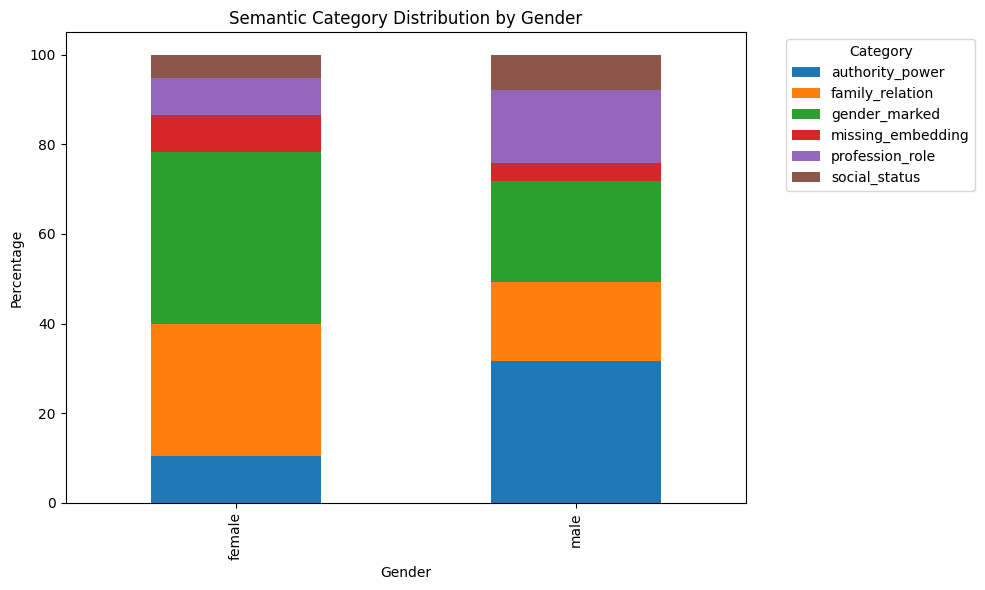

In [ ]:
import matplotlib.pyplot as plt

pivot = gender_category_counts.pivot(
    index="gender_side",
    columns="assigned_category",
    values="percentage"
).fillna(0)

pivot.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Semantic Category Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Manual Validation

A table is generated to inspect classification results and identify potential misclassifications.

In [19]:
validation_table = df[[
    "main_term",
    "gender_side",
    "relation_type",
    "related_term",
    "clean_term",
    "assigned_category",
    "similarity_score"
]].sort_values(by="similarity_score")

validation_table.head(30)

,main_term,gender_side,relation_type,related_term,clean_term,assigned_category,similarity_score
47,emperor,male,hyponym,tenno,tenno,family_relation,-0.296199
67,actor,male,hyponym,mummer,mummer,gender_marked,-0.243378
328,god,male,hyponym,zombi,zombi,gender_marked,-0.207690
146,male parent,male,hyponym,pappa,pappa,family_relation,-0.193297
253,wife,female,hyponym,vicereine,vicereine,gender_marked,-0.183682
221,husband,male,hyponym,househusband,househusband,profession_role,-0.148549
74,actor,male,hyponym,reenactor,reenactor,profession_role,-0.140976
162,female parent,female,hyponym,mumma,mumma,family_relation,-0.135682
95,actress,female,hyponym,tragedienne,tragedienne,gender_marked,-0.118118
98,waiter,male,hyponym,carhop,carhop,profession_role,-0.097040


### Export for Review

The validation table is exported to support manual inspection and correction of the results.

In [20]:
validation_table.to_csv("manual_validation_table.csv", index=False)